In [1]:
# защита от падения ядра IPython
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import random
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns

In [3]:
from src.train import train_resnet_model
from src.inference import inference_resnet_model

In [4]:
SEED = 0xDEAD

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [5]:
class FFTDataset3D(Dataset):
    def __init__(self, channel_1_files, labels):
        self.data = []
        for channel_1_file in channel_1_files:
            channel_1_data = np.load(channel_1_file)
            channel_2_file = ['2' if part == '1' else part for part in channel_1_file.parts]
            channel_2_data = np.load(Path(*channel_2_file))
            channel_3_file = ['3' if part == '1' else part for part in channel_1_file.parts]
            channel_3_data = np.load(Path(*channel_3_file))
            full_data = np.zeros((3, channel_1_data.shape[0], channel_1_data.shape[1]))
            full_data[0, :, :] = channel_1_data
            full_data[1, :, :] = channel_2_data
            full_data[2, :, :] = channel_3_data
            self.data.append(torch.FloatTensor(full_data))
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index], self.labels[index]


def get_multiclass_dataloaders_3d(folders_list,
                                  all_data_samples = None,
                                  mapping = None,
                                  test_size = 0.25,
                                  seed = SEED,
                                  batch_size = 32):
    fft_list = []
    labels_list = []
    for i, signal_type in enumerate(folders_list):
        class_list = list(Path(signal_type).rglob('*.npy'))
        if all_data_samples is not None:
            class_list = class_list[:all_data_samples]
        fft_list += class_list
        label = None if mapping is None else mapping.get(i)
        label = label if label is not None else i
        labels_list += [label for _ in range(len(class_list))]
    Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=seed, test_size=test_size)
    Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=seed, test_size=test_size)
    train_dataset = FFTDataset3D(Xtrain, ytrain)
    val_dataset = FFTDataset3D(Xval, yval)
    test_dataset = FFTDataset3D(Xtest, ytest)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [7]:
signals_list = [
    '../data/processed_engine_2/1st_load_60/1/1727785030/ours_spectrogram',
    '../data/processed_engine_2/2nd_load_60/1/1727789712/ours_spectrogram',
    '../data/processed_engine_2/3rd_load_60/1/1727863902/ours_spectrogram',
    '../data/processed_engine_2/4th_load_60/1/1727935897/ours_spectrogram'
    ]
train, val, test = get_multiclass_dataloaders_3d(signals_list, all_data_samples=2000)

In [8]:
class ResidualBlock3d(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock3d, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = F.relu(self.bn1(out))
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = F.relu(out)
        return out


class ResNet3d(nn.Module):

    def __init__(self, block, layers, num_classes=2):
        super(ResNet3d, self).__init__()
        self.in_channels = 64
        self.conv = nn.Conv2d(
            3, 64, kernel_size=7, stride=2, padding=3)
        self.bn = nn.BatchNorm2d(64)
        self.layer1 = self.make_layer(block, 64, layers[0])
        self.layer2 = self.make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self.make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self.make_layer(block, 512, layers[3], stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if (stride != 1) or (self.in_channels != out_channels):
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels))
        layers = []
        layers.append(
            block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn(self.conv(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avg_pool(out)
        out = out.squeeze()
        out = self.fc(out)
        return out

In [9]:
EPOCHS = 2
model = ResNet3d(ResidualBlock3d, [2, 2, 2, 2], num_classes=4).to(device)

train_resnet_model(model, train, val, device, EPOCHS)

Epoch 1/2:   0%|          | 0/141 [00:00<?, ?batch/s]

Epoch [1/2], Loss: 0.0171
Validation Loss: 0.0000, Accuracy: 100.00%
[✓]   New best (multiclass) saved →  ..\res\checkpoints\resnet_best_multiclass.pth  (metric=1.0000)
  [✓] best model saved → ../res/checkpoints


Epoch 2/2:   0%|          | 0/141 [00:00<?, ?batch/s]

Epoch [2/2], Loss: 0.0000
Validation Loss: 0.0000, Accuracy: 100.00%


ResNet3d(
  (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): ResidualBlock3d(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResidualBlock3d(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): Sequential(
    (0): Residu

In [10]:
target, pred = inference_resnet_model(model, test, device)

Inference:   0%|          | 0/63 [00:00<?, ?batch/s]

In [11]:
f1_score(target, pred, average='micro')

1.0

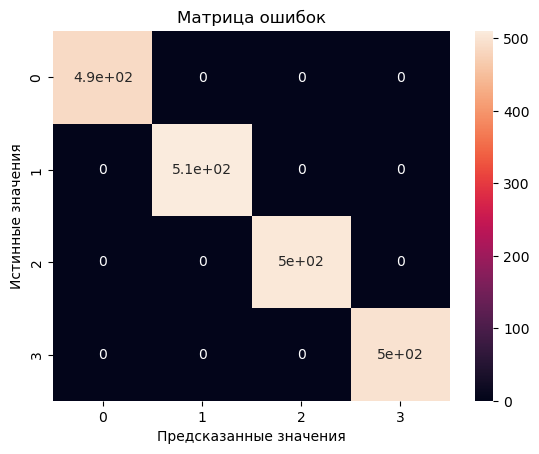

In [12]:
sns.heatmap(confusion_matrix(target, pred), annot=True)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок')
plt.show()

Попробуем самописный ResNet.

In [10]:
class MyResNet2dLayer(torch.nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size_1, kernel_size_2, padding=0, stride=1):
        super().__init__()
        self.input = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=in_channels,
                            out_channels=in_channels,
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm2d(in_channels),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=in_channels,
                            out_channels=out_channels,
                            kernel_size=kernel_size_1,
                            padding=padding,
                            stride=stride),
            torch.nn.BatchNorm2d(out_channels),
        )
        self.residual = torch.nn.Sequential(
            torch.nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size_2,
                padding=padding,
                stride=stride
            )
        )
        self.activation = torch.nn.ReLU()

    def forward(self, x):
        return self.activation(self.input(x) + self.residual(x))
    

class MyResNet2d(torch.nn.Module):
    def __init__(self, in_channels=1, out_features=1):
        super().__init__()
        self.seq  = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=in_channels,
                            out_channels=in_channels,
                            kernel_size=7,
                            stride=2),
            torch.nn.BatchNorm2d(in_channels),
            torch.nn.MaxPool2d(kernel_size=3),
            MyResNet2dLayer(in_channels=in_channels,
                          out_channels=in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            MyResNet2dLayer(in_channels=in_channels,
                          out_channels=2*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            MyResNet2dLayer(in_channels=2*in_channels, 
                          out_channels=2*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            MyResNet2dLayer(in_channels=2*in_channels, 
                          out_channels=4*in_channels,
                          kernel_size_1=3, 
                          kernel_size_2=5),
            MyResNet2dLayer(in_channels=4*in_channels,
                          out_channels=4*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            MyResNet2dLayer(in_channels=4*in_channels, 
                          out_channels=8*in_channels, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            torch.nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = torch.nn.Linear(in_features=8*in_channels, out_features=out_features)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        out = self.sigmoid(self.fc(self.seq(x).squeeze()).squeeze())
        if x.size(0) == 1:
            out = out.unsqueeze(0)
        return out

In [14]:
EPOCHS = 2
my_model = MyResNet2d(in_channels=3, out_features=4).to(device)

train_resnet_model(my_model, train, val, device, EPOCHS)

Epoch 1/2:   0%|          | 0/141 [00:00<?, ?batch/s]

Epoch [1/2], Loss: 0.9982
Validation Loss: 0.9394, Accuracy: 74.87%
[✓]   New best (multiclass) saved →  ..\res\checkpoints\resnet_best_multiclass.pth  (metric=0.7487)
  [✓] best model saved → ../res/checkpoints


Epoch 2/2:   0%|          | 0/141 [00:00<?, ?batch/s]

Epoch [2/2], Loss: 0.8643
Validation Loss: 0.8100, Accuracy: 74.87%


MyResNet2d(
  (seq): Sequential(
    (0): Conv2d(3, 3, kernel_size=(7, 7), stride=(2, 2))
    (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (3): MyResNet2dLayer(
      (input): Sequential(
        (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1))
        (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1))
        (4): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (residual): Sequential(
        (0): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1))
      )
      (activation): ReLU()
    )
    (4): MyResNet2dLayer(
      (input): Sequential(
        (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1))
        (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): 

In [15]:
target, pred = inference_resnet_model(my_model, test, device)
f1_score(target, pred, average='micro')

Inference:   0%|          | 0/63 [00:00<?, ?batch/s]

0.7475

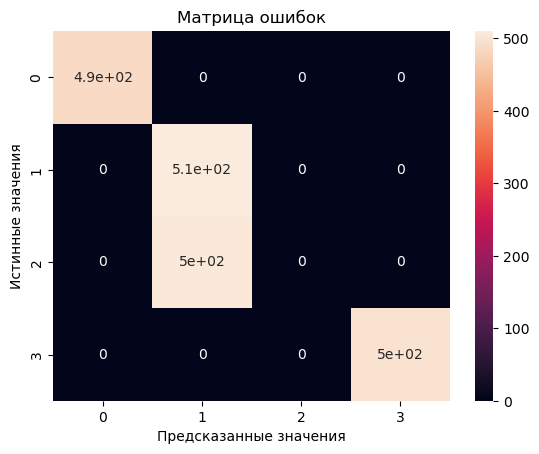

In [16]:
sns.heatmap(confusion_matrix(target, pred), annot=True)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок')
plt.show()

In [8]:
class LittleNet(torch.nn.Module):
    def __init__(self, in_channels=1, out_features=1):
        super().__init__()
        self.seq  = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=in_channels,
                            out_channels=in_channels,
                            kernel_size=7,
                            stride=2),
            torch.nn.BatchNorm2d(in_channels),
            torch.nn.MaxPool2d(kernel_size=3),
            MyResNet2dLayer(in_channels=in_channels,
                          out_channels=64, 
                          kernel_size_1=3, 
                          kernel_size_2=5),
            torch.nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = torch.nn.Linear(in_features=64, out_features=out_features)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        out = self.sigmoid(self.fc(self.seq(x).squeeze()).squeeze())
        if x.size(0) == 1:
            out = out.unsqueeze(0)
        return out

In [11]:
EPOCHS = 2
little_model = LittleNet(in_channels=3, out_features=4).to(device)

train_resnet_model(little_model, train, val, device, EPOCHS)

Epoch 1/2:   0%|          | 0/141 [00:00<?, ?batch/s]

Epoch [1/2], Loss: 1.2087
Validation Loss: 1.0544, Accuracy: 100.00%
[✓]   New best (multiclass) saved →  ..\res\checkpoints\resnet_best_multiclass.pth  (metric=1.0000)
  [✓] best model saved → ../res/checkpoints


Epoch 2/2:   0%|          | 0/141 [00:00<?, ?batch/s]

Epoch [2/2], Loss: 0.9778
Validation Loss: 0.9187, Accuracy: 74.47%


LittleNet(
  (seq): Sequential(
    (0): Conv2d(3, 3, kernel_size=(7, 7), stride=(2, 2))
    (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
    (3): MyResNet2dLayer(
      (input): Sequential(
        (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1))
        (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (residual): Sequential(
        (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
      )
      (activation): ReLU()
    )
    (4): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (fc): Linear(in_features=64, out_features=4, bias=True)
  (sigmoid): Sigmoid()
)

In [14]:
target, pred = inference_resnet_model(little_model, test, device)
f1_score(target, pred, average='micro')

Inference:   0%|          | 0/63 [00:00<?, ?batch/s]

1.0

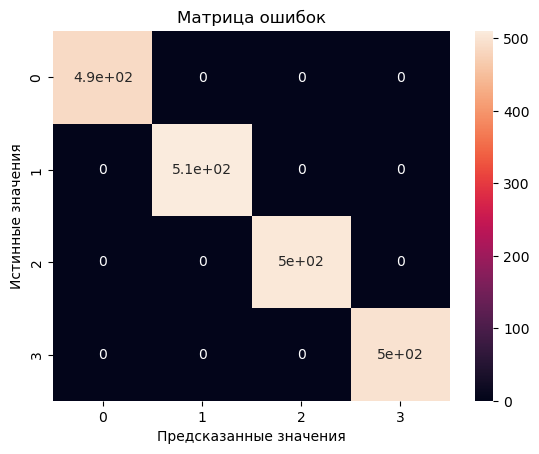

In [15]:
sns.heatmap(confusion_matrix(target, pred), annot=True)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок')
plt.show()